# Which storms, and which links

Two choices come before any comparison, and both are made by code rather than by eye.

**Events.** MRMS finds every precipitation event over the city in the OpenMesh period; MRMS
precipitation type plus ASOS present weather classify each as rain, snow or mix. Method:
`docs/EVENTS.md`. The catalog is `events/all_detected_events.csv`.

**Links.** Of 103 sublinks, most cannot measure rain: 5-6 GHz barely attenuates, very short paths
accumulate too little, some links drop out in rain. The selection chains the checks the original
implementations applied by hand, calibrated on PWS gauges only, on rain events that are *not*
used for evaluation.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nyc_rain_maps import plots

from core.opensense import openmesh as om
from nyc_rain_maps import events
from nyc_rain_maps.link_selection import load_or_select
from nyc_rain_maps.pipeline import SHARED8

In [2]:
cat = pd.read_csv("../events/all_detected_events.csv")
cat["month"] = pd.to_datetime(cat.start).dt.to_period("M")
record = cat[cat.in_openmesh]
print(f"{len(cat)} events detected; {len(record)} inside the OpenMesh record")
record.groupby("ptype").agg(events=("event_id", "size"), total_mm=("total_mm", "sum"),
                            largest_mm=("total_mm", "max")).round(1)

105 events detected; 52 inside the OpenMesh record


,events,total_mm,largest_mm
ptype,,,
mix,3,48.2,18.4
rain,47,885.0,72.0
snow,2,9.2,7.5


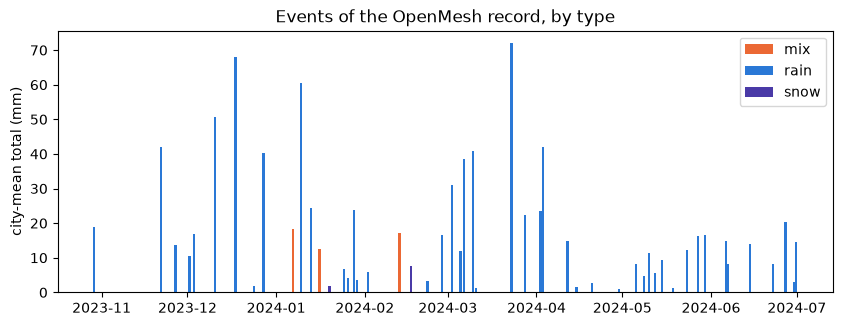

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.4))
for ptype, g in record.groupby("ptype"):
    ax.bar(pd.to_datetime(g.start), g.total_mm, width=0.8, color=plots.PTYPE_COLORS[ptype], label=ptype)
ax.set(ylabel="city-mean total (mm)", title="Events of the OpenMesh record, by type")
ax.legend();

The evaluation catalog is the five largest events of each type (`selected`). The 2023-24 winter
was snow-poor, so snow and mix are completed from other winters where there is no link data;
those are marked `in_openmesh = False` and have radar and ASOS only.

In [4]:
cat[cat.selected].sort_values(["ptype", "rank"])[
    ["ptype", "rank", "start", "end", "total_mm", "snow_fraction", "min_temp_c", "in_openmesh"]]

,ptype,rank,start,end,total_mm,snow_fraction,min_temp_c,in_openmesh
9,mix,1,2024-01-06 19:00:00,2024-01-07 18:00:00,18.40,0.044795,0.6,True
19,mix,2,2024-02-13 03:00:00,2024-02-13 18:00:00,17.19,0.235556,0.0,True
12,mix,3,2024-01-16 03:00:00,2024-01-16 21:00:00,12.63,0.968790,-4.0,True
64,mix,4,2022-01-16 23:00:00,2022-01-17 15:00:00,42.54,0.121794,-2.2,False
75,mix,5,2023-01-25 18:00:00,2023-01-26 09:00:00,35.47,0.000000,1.7,False
28,rain,1,2024-03-23 06:00:00,2024-03-23 22:00:00,72.04,0.000000,3.3,True
6,rain,2,2023-12-17 18:00:00,2023-12-18 19:00:00,68.01,0.000000,9.4,True
10,rain,3,2024-01-09 16:00:00,2024-01-10 11:00:00,60.38,0.000000,6.1,True
5,rain,4,2023-12-10 16:00:00,2023-12-11 15:00:00,50.80,0.000000,3.0,True
1,rain,5,2023-11-21 18:00:00,2023-11-22 11:00:00,42.14,0.000000,6.1,True


## Link selection

Stages (details: `results/link_selection/README.md`):

0. metadata: 10-100 GHz, 0.3-20 km, inside the city
1. contact loss: at most 40% of minutes missing while the nearby gauges report rain
2. rain response: wet/dry skill and correlation with nearby gauges
3. accumulation: total within 40% of the gauges
4. one sublink per path

It is computed once and saved; `python src/run.py select` recomputes it.

In [5]:
sel = load_or_select()
print("selected:", sel.selected)
print("calibration events:", len(sel.calibration_events))
sel.summary()["rejected_by_stage"]

selected: ['3/sublink_3', '8/sublink_1', '12/sublink_2', '20/sublink_2', '31/sublink_1', '34/sublink_1', '40/sublink_1']
calibration events: 31


{'0 metadata': 64,
 '1 contact loss': 4,
 '2 rain response': 19,
 '3 accumulation': 6,
 '4 one per path': 3}

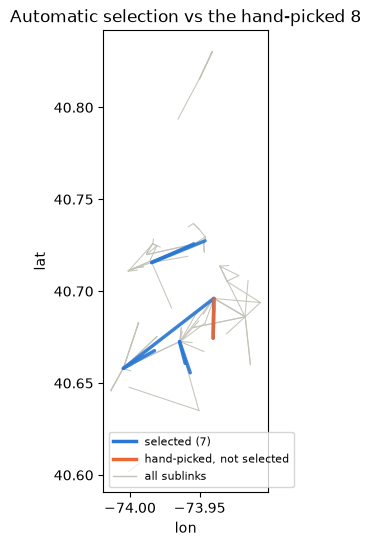

In [6]:
table = om.sublinks_table()
fig, ax = plt.subplots(figsize=(6.5, 6))
plots.draw_links(ax, table, color="#c3c2b7", lw=0.8)
plots.draw_links(ax, table.loc[sel.selected], color="#2a78d6", lw=2.5)
plots.draw_links(ax, table.loc[[x for x in SHARED8 if x not in sel.selected]], color="#eb6834", lw=2.5)
ax.plot([], [], color="#2a78d6", lw=2.5, label=f"selected ({len(sel.selected)})")
ax.plot([], [], color="#eb6834", lw=2.5, label="hand-picked, not selected")
ax.plot([], [], color="#c3c2b7", lw=1, label="all sublinks")
ax.set(xlabel="lon", ylabel="lat", title="Automatic selection vs the hand-picked 8")
ax.set_aspect(1 / np.cos(np.radians(40.7)))
ax.legend(fontsize=8);

The automatic selection recovers 7 of the 8 links the original authors picked by hand. The
eighth, `45/sublink_1`, is the same path as `40/sublink_1` in the opposite direction, so
stage 4 keeps only one of them.

Next: `03_one_event.ipynb`.